# Headcount Attrition - Survival Analysis

**Objective:** predict who is likely to resign and when, using the public IBM HR Analytics dataset.
**Method:** classification (Logistic Regression / Random Forest / Gradient Boosting, compared and tuned) for *who*; Cox Proportional Hazards survival analysis for *when*. Results are assembled into an auto-generated executive PowerPoint report.

In [1]:
import os
import re
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, average_precision_score, classification_report,
)
from scipy.stats import randint, uniform, loguniform

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from pptx import Presentation
from pptx.util import Inches, Pt

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

CONFIG = {
    "DATA_PATH": "../data/IBM-HR-Employee-Attrition.csv",
    "RESULT_DIR": "../result/",
    "RANDOM_STATE": 42
}
RANDOM_STATE = CONFIG["RANDOM_STATE"]

for folder in ["figures", "slides"]:
    Path(os.path.join(CONFIG["RESULT_DIR"], folder)).mkdir(parents=True, exist_ok=True)

FIG_DIR = os.path.join(CONFIG["RESULT_DIR"], "figures")
SLD_DIR = os.path.join(CONFIG["RESULT_DIR"], "slides")

## STEP 01 - Load and Clean Data

Drop constant columns and the row-identifier column, since neither carries predictive signal.

In [2]:
def clean_feature_label(name):
    name = name.replace('_', ' ')
    name = re.sub(r'([a-z])([A-Z])', r'\1 \2', name)
    return name.replace(' Yes', ' (Yes)').replace(' No', ' (No)').strip().title()

df = pd.read_csv(CONFIG["DATA_PATH"])
EMPLOYEE_IDS = df["EmployeeNumber"].copy()

CONST_COLS = [c for c in df.columns if df[c].nunique() == 1]
DROP_COLS = CONST_COLS + ["EmployeeNumber"]
print(f"Dropping constant/ID columns: {DROP_COLS}")
df = df.drop(columns=DROP_COLS)

X = df.drop("Attrition", axis=1)
y = df["Attrition"].apply(lambda x: 1 if x == "Yes" else 0)

print(f"Dataset: {df.shape[0]} employees, {X.shape[1]} features")
print(f"Attrition rate: {y.mean():.1%} ({y.sum()} of {len(y)} employees left)")

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    verbose_feature_names_out=False
)

Dropping constant/ID columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Dataset: 1470 employees, 30 features
Attrition rate: 16.1% (237 of 1470 employees left)


## STEP 02 - Exploratory Data Analysis

Target is imbalanced (~16% attrition), so ROC-AUC and recall are tracked alongside accuracy throughout.

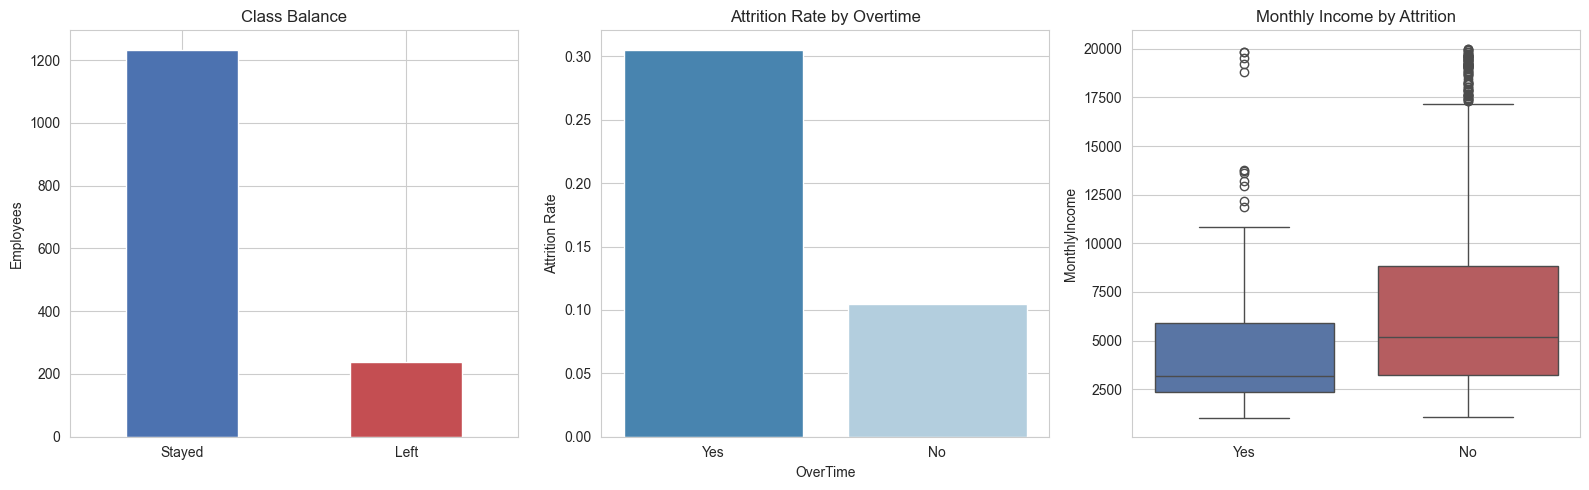

In [3]:
plot_df = df.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

y.value_counts().rename({0: "Stayed", 1: "Left"}).plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"]
)
axes[0].set_title("Class Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Employees")
axes[0].tick_params(axis='x', rotation=0)

plot_df["Attrition_Flag"] = y.values
sns.barplot(x="OverTime", y="Attrition_Flag", data=plot_df, ax=axes[1],
            hue="OverTime", palette="Blues_r", legend=False, errorbar=None)
axes[1].set_title("Attrition Rate by Overtime")
axes[1].set_ylabel("Attrition Rate")

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, ax=axes[2],
            hue="Attrition", palette=["#4C72B0", "#C44E52"], legend=False)
axes[2].set_title("Monthly Income by Attrition")
axes[2].set_xlabel("")

plt.tight_layout()
eda_img_path = os.path.join(FIG_DIR, "eda_overview.png")
plt.savefig(eda_img_path, dpi=300)
plt.show()

## STEP 03 - Model Comparison

5-fold stratified cross-validation on ROC-AUC across three classifiers, `class_weight='balanced'` where supported.

Logistic Regression  ROC-AUC = 0.827 (+/- 0.028)


Random Forest        ROC-AUC = 0.800 (+/- 0.027)


Gradient Boosting    ROC-AUC = 0.813 (+/- 0.016)

Best model by cross-validated ROC-AUC: Logistic Regression


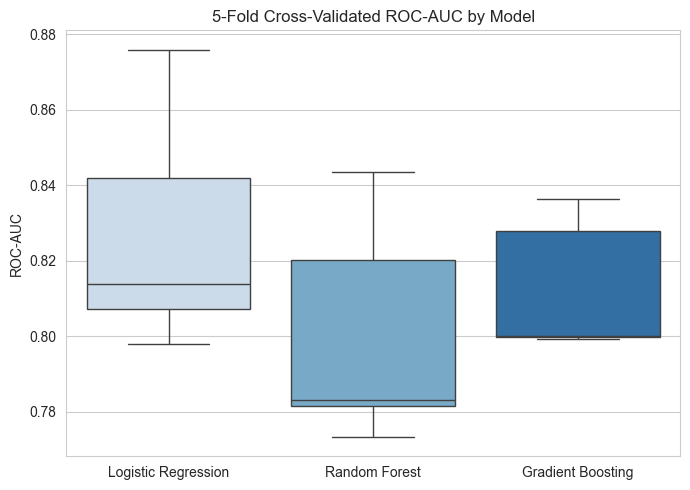

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = {}
for name, clf in candidates.items():
    scores = cross_val_score(clf, X_train_proc, y_train, cv=cv, scoring="roc_auc")
    cv_scores[name] = scores
    print(f"{name:20s} ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

best_model_name = max(cv_scores, key=lambda k: cv_scores[k].mean())
print(f"\nBest model by cross-validated ROC-AUC: {best_model_name}")

plt.figure(figsize=(7, 5))
sns.boxplot(data=pd.DataFrame(cv_scores), palette="Blues")
plt.title("5-Fold Cross-Validated ROC-AUC by Model")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "model_comparison.png"), dpi=300)
plt.show()

## STEP 04 - Hyperparameter Tuning and Final Evaluation

Randomized search (25 iterations, same CV) on the best model from above, evaluated once on the held-out test set.

In [5]:
PARAM_DISTS = {
    "Logistic Regression": {
        "C": loguniform(1e-3, 1e2),
    },
    "Random Forest": {
        "n_estimators": randint(150, 500),
        "max_depth": randint(3, 20),
        "min_samples_leaf": randint(1, 8),
        "max_features": ["sqrt", "log2"],
    },
    "Gradient Boosting": {
        "n_estimators": randint(100, 400),
        "learning_rate": uniform(0.01, 0.19),
        "max_depth": randint(2, 5),
    },
}

search = RandomizedSearchCV(
    candidates[best_model_name],
    param_distributions=PARAM_DISTS[best_model_name],
    n_iter=25,
    cv=cv,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train_proc, y_train)
best_model = search.best_estimator_
print(f"Best params: {search.best_params_}")
print(f"Best CV ROC-AUC: {search.best_score_:.3f}")

y_pred = best_model.predict(X_test_proc)
y_proba = best_model.predict_proba(X_test_proc)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "PR-AUC": average_precision_score(y_test, y_proba),
}
print(f"\nTest-set performance -- {best_model_name} (tuned):")
for k, v in metrics.items():
    print(f"  {k:10s}: {v:.3f}")

print("\n" + classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))

Best params: {'C': np.float64(0.0745934328572655)}
Best CV ROC-AUC: 0.831

Test-set performance -- Logistic Regression (tuned):
  Accuracy  : 0.779
  Precision : 0.390
  Recall    : 0.681
  F1        : 0.496
  ROC-AUC   : 0.812
  PR-AUC    : 0.593

              precision    recall  f1-score   support

      Stayed       0.93      0.80      0.86       247
        Left       0.39      0.68      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.74      0.68       294
weighted avg       0.84      0.78      0.80       294



## STEP 05 - Diagnostic Visualizations

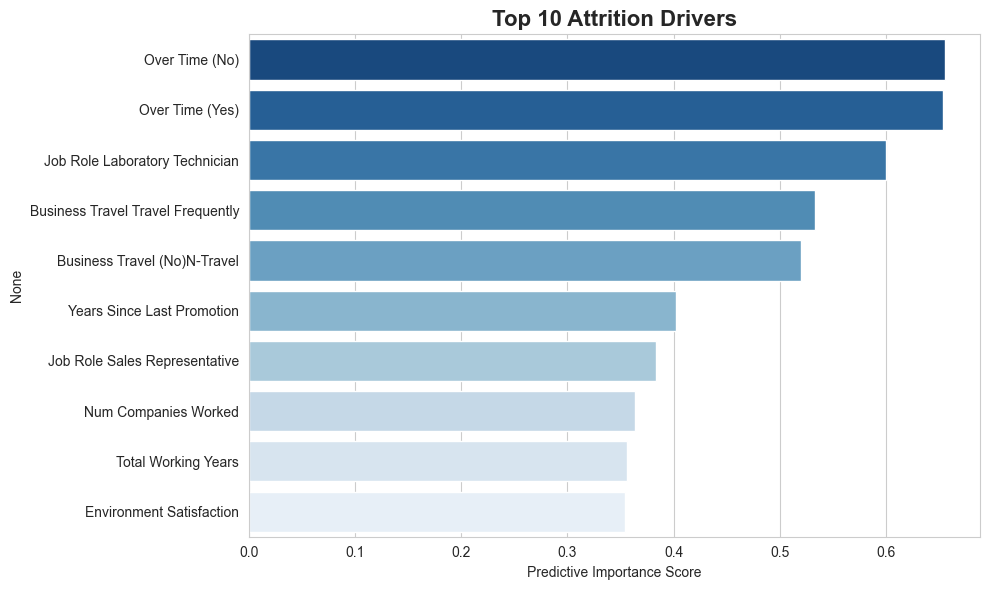

In [6]:
if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
else:
    importance_values = np.abs(best_model.coef_[0])

importance = pd.Series(importance_values, index=preprocessor.get_feature_names_out())
top_10 = importance.sort_values(ascending=False).head(10)
top_10.index = [clean_feature_label(n) for n in top_10.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10.values, y=top_10.index, hue=top_10.index, palette="Blues_r", legend=False)
plt.title("Top 10 Attrition Drivers", fontsize=16, fontweight='bold')
plt.xlabel("Predictive Importance Score")
plt.tight_layout()
feat_img_path = os.path.join(FIG_DIR, "top_10_features.png")
plt.savefig(feat_img_path, dpi=300)
plt.show()

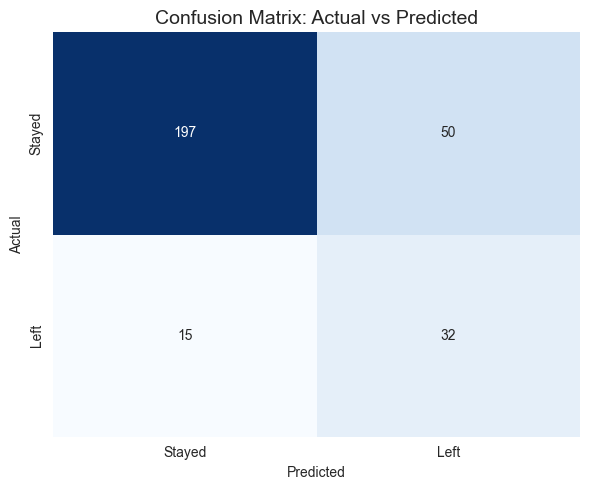

In [7]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title("Confusion Matrix: Actual vs Predicted", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
cm_img_path = os.path.join(FIG_DIR, "confusion_matrix.png")
plt.savefig(cm_img_path, dpi=300)
plt.show()

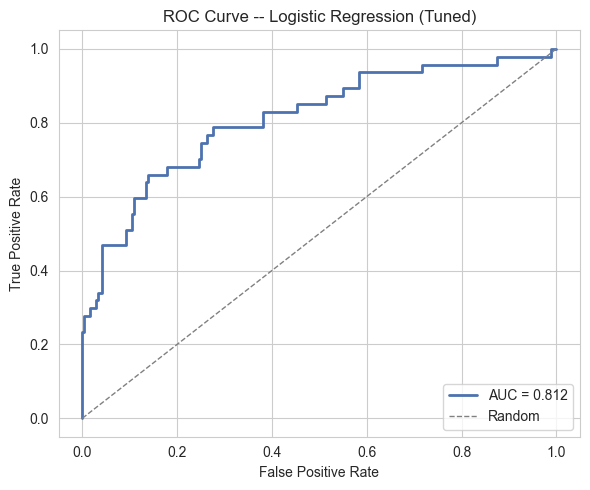

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {metrics['ROC-AUC']:.3f}")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve -- {best_model_name} (Tuned)")
plt.legend(loc="lower right")
plt.tight_layout()
roc_img_path = os.path.join(FIG_DIR, "roc_curve.png")
plt.savefig(roc_img_path, dpi=300)
plt.show()

## STEP 06 - Survival Analysis (Cox Proportional Hazards)

Classification predicts *who* is at risk; this models *when*, using tenure (`YearsAtCompany`) as time-to-event. Employees who left are an observed event; employees still with the company are right-censored.

In [9]:
SURVIVAL_COVARIATES = [
    "OverTime", "JobLevel", "MonthlyIncome", "JobSatisfaction", "WorkLifeBalance",
    "YearsSinceLastPromotion", "DistanceFromHome", "StockOptionLevel",
    "NumCompaniesWorked", "Age", "MaritalStatus",
]

surv_df = df[["YearsAtCompany", "Attrition"] + SURVIVAL_COVARIATES].copy()
surv_df["event"] = (surv_df["Attrition"] == "Yes").astype(int)
surv_df["duration"] = surv_df["YearsAtCompany"].clip(lower=0.5)
surv_df = surv_df.drop(columns=["Attrition", "YearsAtCompany"])

surv_df = pd.get_dummies(surv_df, columns=["OverTime", "MaritalStatus"], drop_first=True)
surv_df.columns = [c if c in ("duration", "event") else clean_feature_label(c) for c in surv_df.columns]
surv_df = surv_df.astype(float)

surv_train, surv_test = train_test_split(
    surv_df, test_size=0.2, random_state=RANDOM_STATE, stratify=surv_df["event"]
)

cph = CoxPHFitter(penalizer=0.1)
cph.fit(surv_train, duration_col="duration", event_col="event")

test_cindex = concordance_index(
    surv_test["duration"], -cph.predict_partial_hazard(surv_test), surv_test["event"]
)
print(f"Train concordance index (C-index): {cph.concordance_index_:.3f}")
print(f"Test  concordance index (C-index): {test_cindex:.3f}")
print("(0.5 = random guessing, 1.0 = perfect ranking of who leaves first -- same scale as ROC-AUC)")

Train concordance index (C-index): 0.849
Test  concordance index (C-index): 0.846
(0.5 = random guessing, 1.0 = perfect ranking of who leaves first -- same scale as ROC-AUC)


,coef,exp(coef),p
covariate,,,
Over Time (Yes),0.698,2.010,0.000
Marital Status Single,0.359,1.431,0.011
Num Companies Worked,0.084,1.088,0.000
Distance From Home,0.016,1.017,0.017
Monthly Income,-0.000,1.000,0.001
Age,-0.038,0.963,0.000
Years Since Last Promotion,-0.058,0.944,0.002
Marital Status Married,-0.081,0.922,0.531
Job Satisfaction,-0.128,0.880,0.012


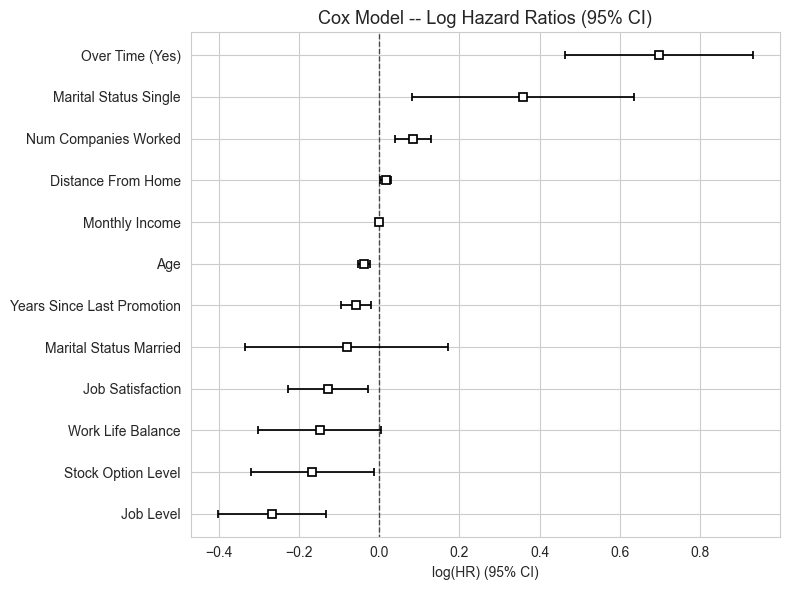

In [10]:
cox_summary = cph.summary.sort_values("exp(coef)", ascending=False)
display(cox_summary[["coef", "exp(coef)", "p"]].round(3))

plt.figure(figsize=(8, 6))
cph.plot()
plt.title("Cox Model -- Log Hazard Ratios (95% CI)", fontsize=13)
plt.tight_layout()
cox_forest_path = os.path.join(FIG_DIR, "cox_hazard_ratios.png")
plt.savefig(cox_forest_path, dpi=300)
plt.show()

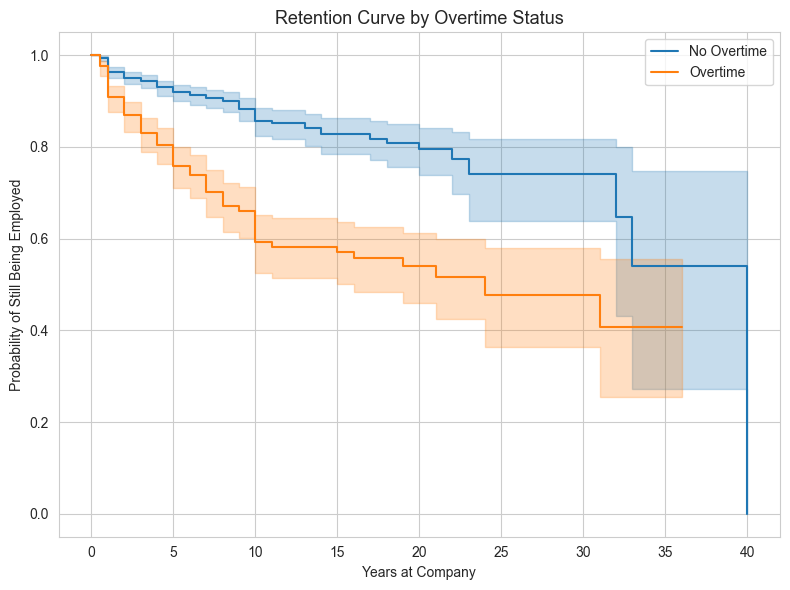

Log-rank test (Overtime vs No Overtime): p = 1.58e-19


In [11]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 6))
for label, mask in [("No Overtime", df["OverTime"] == "No"), ("Overtime", df["OverTime"] == "Yes")]:
    kmf.fit(
        durations=df.loc[mask, "YearsAtCompany"].clip(lower=0.5),
        event_observed=(df.loc[mask, "Attrition"] == "Yes").astype(int),
        label=label,
    )
    kmf.plot_survival_function(ax=ax)

plt.title("Retention Curve by Overtime Status", fontsize=13)
plt.xlabel("Years at Company")
plt.ylabel("Probability of Still Being Employed")
plt.tight_layout()
km_img_path = os.path.join(FIG_DIR, "km_overtime.png")
plt.savefig(km_img_path, dpi=300)
plt.show()

mask_ot = df["OverTime"] == "Yes"
lr = logrank_test(
    df.loc[mask_ot, "YearsAtCompany"], df.loc[~mask_ot, "YearsAtCompany"],
    event_observed_A=(df.loc[mask_ot, "Attrition"] == "Yes").astype(int),
    event_observed_B=(df.loc[~mask_ot, "Attrition"] == "Yes").astype(int),
)
print(f"Log-rank test (Overtime vs No Overtime): p = {lr.p_value:.2e}")

## STEP 07 - Flag Current Employees at Highest Risk

In [12]:
current = surv_df[surv_df["event"] == 0].copy()
current["Employee ID"] = EMPLOYEE_IDS.loc[current.index].values
current["Risk Score"] = cph.predict_partial_hazard(current)
current["Predicted Median Tenure (Years)"] = cph.predict_median(current)

at_risk = current.sort_values("Risk Score", ascending=False).head(10)
at_risk_display = at_risk[["Employee ID", "duration", "Risk Score", "Predicted Median Tenure (Years)"]].rename(
    columns={"duration": "Tenure So Far (Years)"}
)
display(at_risk_display.round(2))

,Employee ID,Tenure So Far (Years),Risk Score,Predicted Median Tenure (Years)
909,1269,1.0,8.26,5.0
1436,2021,2.0,7.89,5.0
841,1173,4.0,7.11,5.0
318,434,4.0,6.39,6.0
618,854,4.0,6.19,7.0
1137,1605,4.0,6.06,7.0
1311,1839,0.5,5.90,7.0
673,939,3.0,5.76,7.0
1460,2054,5.0,5.59,7.0
815,1131,2.0,5.38,7.0


## STEP 08 - Executive PowerPoint Report

Remarks are generated dynamically from the fitted models, not hardcoded.

In [13]:
def add_metrics_slide(prs, img_path, metrics_dict, remarks, title_text):
    slide = prs.slides.add_slide(prs.slide_layouts[6])

    title = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(9), Inches(1))
    title.text_frame.text = title_text
    title.text_frame.paragraphs[0].font.size, title.text_frame.paragraphs[0].font.bold = Pt(28), True

    slide.shapes.add_picture(img_path, Inches(0.5), Inches(1.5), width=Inches(5.2))

    tx_box = slide.shapes.add_textbox(Inches(6.0), Inches(1.5), Inches(3.5), Inches(5))
    tf = tx_box.text_frame
    tf.word_wrap = True

    p = tf.add_paragraph()
    p.text = "Results:"
    p.font.bold, p.font.size = True, Pt(18)
    for k, v in metrics_dict.items():
        bp = tf.add_paragraph()
        bp.text = f"{k}: {v:.3f}"
        bp.font.size, bp.level = Pt(14), 0

    p = tf.add_paragraph()
    p.text = "\nKey Remarks:"
    p.font.bold, p.font.size = True, Pt(18)
    for remark in remarks:
        bp = tf.add_paragraph()
        bp.text = remark
        bp.font.size, bp.level = Pt(13), 0

    return slide


driver_remarks = [f"{feat} is among the strongest predictors of attrition." for feat in top_10.index[:3]]
driver_remarks.append(f"Best model after tuning: {best_model_name} ({metrics['ROC-AUC']:.1%} ROC-AUC).")

n_correct = accuracy_score(y_test, y_pred, normalize=False)
accuracy_remarks = [
    f"{n_correct} of {len(y_test)} held-out employees ({metrics['Accuracy']:.1%}) were classified correctly.",
    f"The model catches {metrics['Recall']:.1%} of employees who actually left (recall).",
]

top_hazards = cox_summary[cox_summary["p"] < 0.05].sort_values("exp(coef)", ascending=False).head(3)
survival_remarks = [
    (f"{feat} raises the hazard of leaving by {(row['exp(coef)'] - 1) * 100:.0f}%."
     if row["exp(coef)"] >= 1
     else f"{feat} lowers the hazard of leaving by {(1 - row['exp(coef)']) * 100:.0f}%.")
    for feat, row in top_hazards.iterrows()
]
survival_remarks.append(f"Test concordance index: {test_cindex:.3f} (0.5 = random, 1.0 = perfect ranking).")
survival_remarks.append(f"Overtime vs. no-overtime retention gap is statistically significant (log-rank p = {lr.p_value:.1e}).")

prs = Presentation()
add_metrics_slide(
    prs, feat_img_path,
    {"Accuracy": metrics["Accuracy"], "ROC-AUC": metrics["ROC-AUC"], "Recall": metrics["Recall"], "F1": metrics["F1"]},
    driver_remarks,
    "Who Will Resign -- Key Drivers",
)
add_metrics_slide(
    prs, cm_img_path,
    {"Accuracy": metrics["Accuracy"], "Precision": metrics["Precision"], "Recall": metrics["Recall"], "F1": metrics["F1"]},
    accuracy_remarks,
    "Model Accuracy -- Validation",
)
add_metrics_slide(
    prs, km_img_path,
    {"Train C-index": cph.concordance_index_, "Test C-index": test_cindex},
    survival_remarks,
    "When Will They Resign -- Survival Analysis",
)
prs.save(os.path.join(SLD_DIR, "Executive_Attrition_Report.pptx"))
print(f"Report saved to {os.path.join(SLD_DIR, 'Executive_Attrition_Report.pptx')}")

Report saved to ../result/slides\Executive_Attrition_Report.pptx
